# Part 2. Modeling

The following section evaluates whether predictive signals exist and whether they remain robust under realistic deployment conditions. A few machine learning algorithms were trained on 64 feature columns to predict the 3 target columns (target_up_60d, ROI_30d_top30, and future_60d_min_rel).

In [1]:
# Dependencies
from contextlib import contextmanager
from datetime import datetime
from datetime import date, timedelta
from pathlib import Path
from typing import Optional
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import psutil
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from scipy import stats
import eda_starter as eda
from lightgbm import LGBMClassifier, LGBMRegressor
from scipy.stats import spearmanr

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from xgboost import XGBRegressor, XGBClassifier
import shap

import itertools
import signal_helper as signal
from eda.signal_helper import merge_ROI_rank
from template.prelude_template import BACKTEST_START
import ta
import btc_helper as help

In [398]:
import importlib
importlib.reload(signal)

<module 'signal_helper' from 'C:\\Users\\timot\\OneDrive\\Learn\\GT OMSA\\Practicum\\eda\\signal_helper.py'>

## 1. Data and Definitions

In [118]:
# Import data
btc_df = pl.read_parquet("btc_df_final.parquet")

Column Definitions by category, target

In [391]:
COLS = btc_df.columns
EXCLUDE_COLS = ['time','future_30d_avg',
                'ROI_30d_avg',
                'target_up_30d',
                'target_up5_30d',
                'future_30d_vs_30d_SMA',
                'future_30d_min',
                'Price_per_30d_min',
                'target_rank_30d',
                'future_60d_avg',
                'ROI_60d_avg',
                'target_up_60d',
                'target_up5_60d',
                'future_60d_vs_30d_SMA',
                'future_60d_min',
                'Price_per_60d_min',
                'target_rank_60d',
                'ROI_30d',
                'ROI_30d_top30',
                'ROI_60d',
                'ROI_60d_top30','markPrice',
                'PriceUSD',
                'target_up_30d',
                'CapMrktCurUSD',
                'oc_MVRV_high',
                'future_30d_kmin_5',
                'future_60d_kmin_5',
                'Future_30d_min_rel',
                'Future_60d_min_rel',
                # 'smastd_200',
                # 'distance_sma_200'
                #'oc_CapMrktCurUSD_Z',
                ]
TARGET_COL = 'target_up_60d'
INDEX_COL = 'time_basis'

# FEATURE_COLS = 'oc_MVRVCur_Z'
FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL]
POLYMARKET_COL = [
    'poly_dtrade_count',
    'poly_dtrade_active_traders',
    'poly_dtrade_avg_trx',
    'poly_dtrade_trx',
    'poly_dtrade_trx_dir',
    'poly_dtrade_trx_std',
    'odds_markets',
    'odds_avg',
    'odds_dispersion',
    'odds_breadth',
    'odds_momentum',
    'odds_long_market',
    'odds_long_avg',
    'odds_short_market',
    'odds_short_avg',
    'odds_duration_divergence',
    'poly_dtrade_trx_zscore',
    'poly_dtrade_trx_dir_zscore',
    'odds_avg_zscore',
    'odds_long_zscore',
    'odds_short_zscore',
    'poly_dtrade_trx_dir_ratio',
]
NON_POLY_FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL and col not in POLYMARKET_COL]
POLYMARKET_START = pl.date(2025,4,7)

ONCHAIN_FEATURES = [
    'AdrActCnt',
    'AdrBalCnt',
    'BlkCnt',
    'CapMVRVCur',
    'FeeTotNtv',
    'HashRate',
    'TxCnt',
    'TxTfrCnt',
    'volume_reported_spot_usd_1d',
    'oc_MVRVCur_Z',
    'oc_MVRVCur_grad',
    'oc_MVRVCur_accel',
    'oc_CapMrktCurUSD_Z',
    'oc_MVRVCur_vol_Z',
    'oc_Puell_proxy',
    'oc_miner_stress',
    'oc_flow_ratio',
    'oc_vol_30d_Z',
    'oc_turnover',
    "oc_MVRVCur_vol_Z",
    "oc_vol_30d_Z"
]
TECHNICAL_FEATURES = [
    'smastd_200',
    'distance_sma_200',
    'emastd_200',
    'distance_ema_200',
    'drawdown',
    'RSI',
    'RSI_zscore',
    "RSI",
    "RSI_zscore"
]
MACRO_FEATURES = [
    'M2SL',
    'WALCL',
    'CPIAUCSL',
    'fed_balance_growth',
    'real_rate',
    'usd_strength',
    '10y_yield',
    'inflation_yoy'
]
BINANCE_FEATURES = [
    'bin_returns_1d',
    'bin_volatility_30d',
    'bin_volume_zscore',
    'funding_rate'
]

## 2. Simple train-test split

1.	Dataset was split into 80% training set and 20% test set. The test set also excluded 60-day purge period to avoid forward leakage from the training set forward looking target metrics.
2.	A 5-fold GridSearchCV was performed on training dataset to optimize hyperparameters for a few sampled supervised machine learning algorithms (XGBoost, Logistic Regression, Random Forest, and LightGBM). The GridSearchCV module utilized TimeSeriesSplit with walk-forward validation to avoid forward data leakage by mixing training data from different time periods.
3.	As the binary classification outputs were highly noisy with less than 60% accuracy, the prediction probabilies were plotted against forward returns (ROI_60d_avg) instead.

In [392]:
X = btc_df[FEATURE_COLS]
y = btc_df[TARGET_COL]
ROI = btc_df[['ROI_60d_avg']]
n_fold = 5
tscv = TimeSeriesSplit(n_splits= n_fold)
X_train, X_test, y_train, y_test, ROI_train, ROI_test = train_test_split(X, y, ROI, test_size=0.1,
                                                                         random_state=42, shuffle=False)

### 2.1 XGBoost on target_up_60d

In [252]:
model = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42
)

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.1],
    'colsample_bytree': [0.6, 0.8],
    'subsample': [0.6, 0.8],
    'reg_lambda': [1, 1.5, 2],
    'reg_alpha': [0, 0.1, 1],
}

In [65]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy', # Choose an appropriate scoring metric
    cv=tscv,
    verbose=1,
    return_train_score=True,
    n_jobs=-1 # Use all available CPU cores
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.6, 0.8], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [300, 500], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

Accuracy score is still quite poor

In [393]:
model = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42,
    colsample_bytree = 0.6,
    learning_rate = 0.01,
    max_depth = 5,
    n_estimators = 300,
    reg_lambda = 2,
    reg_alpha = 1,
    subsample = 0.6
)
model.fit(X_train, y_train)
# {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 1, 'reg_lambda': 2, 'subsample': 0.6}

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [254]:
accuracy_score(model.predict(X_test), y_test)

0.5830388692579506

Instead, we will get the predict_proba output and present them in percentile form to check whether any signal exist.

SignificanceResult(statistic=np.float64(0.6622499432424912), pvalue=np.float64(9.390207458520489e-58))


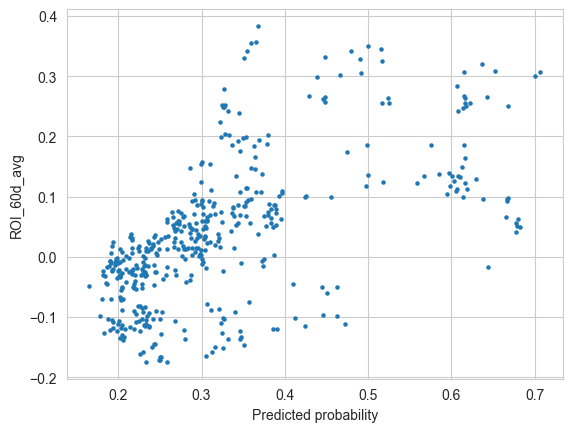

In [255]:
pred_prob = model.predict_proba(X_test)[60:,1]
plt.scatter(pred_prob, ROI_test[60:], s=5)
plt.ylabel('ROI_60d_avg')
plt.xlabel("Predicted probability")
print(spearmanr(pred_prob, ROI_test[60:], nan_policy='omit'))

In [394]:
rank = signal.get_rank(model, X_test, 0, purge_len=60) # Include purge mechanism to avoid data leak
ROI_rank = signal.merge_ROI_rank(ROI_test, rank, purge_len=60)

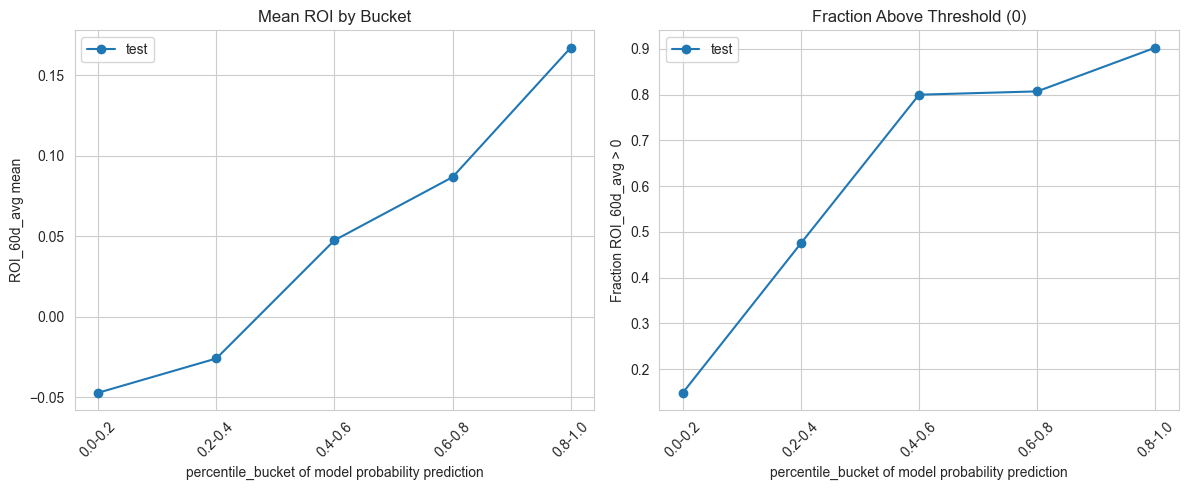

In [399]:
signal.plot_roi_summary_by_bucket(ROI_rank,0)

Of the 4 models, XGBoost demonstrated the strongest correlation and monotonic relationship to probability quintiles. Logistic regression was unable to capture the more complex non-linear relationships in the data. RandomForest and LightGBM had decent performance but XGBoost predicted probabilities showed significantly larger range and higher correlation which is more suitable for strategy integration.

### 2.2. Logistic Regression on target_up_60d

In [258]:
model_LR = LogisticRegression(max_iter=1000,random_state=42)
model_LR.fit(X_train, y_train)
rank_LR = signal.get_rank(model_LR, X, len(X_train), purge_len=60)
ROI_rank_LR = signal.merge_ROI_rank(ROI, rank_LR, purge_len=60)

In [400]:
accuracy_score(model_LR.predict(X_test), y_test)

0.5406360424028268

SignificanceResult(statistic=np.float64(0.31816167682048585), pvalue=np.float64(5.672521393613214e-12))


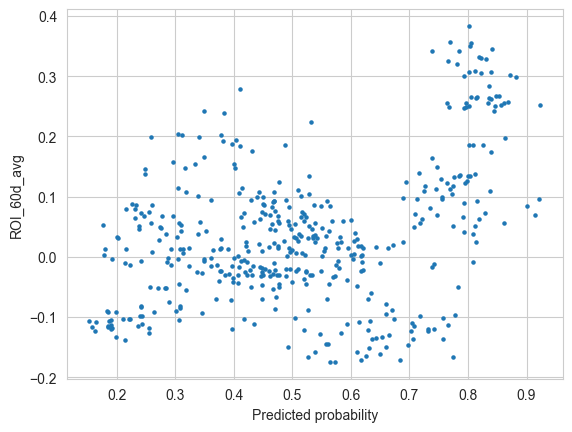

In [260]:
pred_prob_LR = model_LR.predict_proba(X_test)[60:,1]
plt.scatter(pred_prob_LR, ROI_test[60:], s=5)
plt.ylabel('ROI_60d_avg')
plt.xlabel("Predicted probability")
print(spearmanr(pred_prob_LR, ROI_test[60:], nan_policy='omit'))

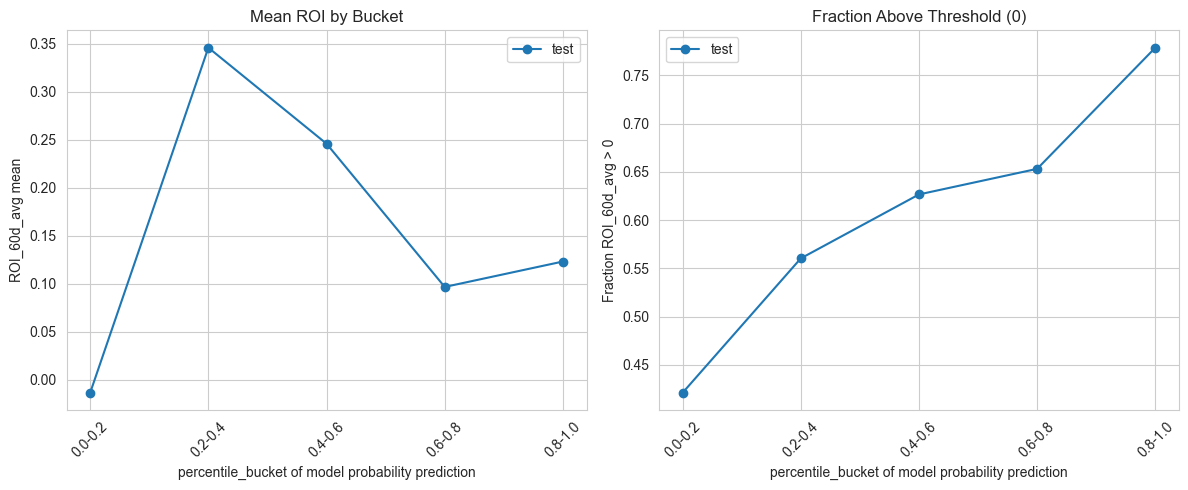

In [401]:
signal.plot_roi_summary_by_bucket(ROI_rank_LR,0)

### 2.3. Random Forest on target_up_60d

In [402]:
model_RF = RandomForestClassifier(random_state=42, criterion='log_loss')
param_grid_RF = {
    'max_depth': [3, 5, 7],
    'n_estimators': [300, 500, 700],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search_RF = GridSearchCV(
    estimator=model_RF,
    param_grid=param_grid_RF,
    scoring='accuracy', # Choose an appropriate scoring metric
    cv=tscv,
    verbose=1,
    return_train_score=True,
    n_jobs=-1 # Use all available CPU cores
)

grid_search_RF.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [2, 4], 'min_samples_split': [5, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [403]:
print(grid_search_RF.best_params_)
print(grid_search_RF.best_score_)
model_RF = grid_search_RF.best_estimator_
rank_RF = signal.get_rank(model_RF, X, len(X_train), purge_len=60)
ROI_rank_RF = signal.merge_ROI_rank(ROI, rank_RF, purge_len=60)

{'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
0.49292452830188677


SignificanceResult(statistic=np.float64(0.5318480101818589), pvalue=np.float64(5.258557015525019e-34))


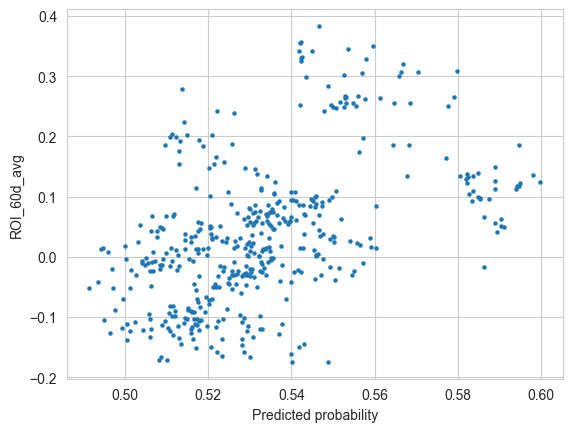

In [404]:
pred_prob_RF = model_RF.predict_proba(X_test)[60:,1]
plt.scatter(pred_prob_RF, ROI_test[60:], s=5)
plt.ylabel('ROI_60d_avg')
plt.xlabel("Predicted probability")
print(spearmanr(pred_prob_RF, ROI_test[60:], nan_policy='omit'))

In [405]:
accuracy_score(model_RF.predict(X_test), y_test)

0.5353356890459364

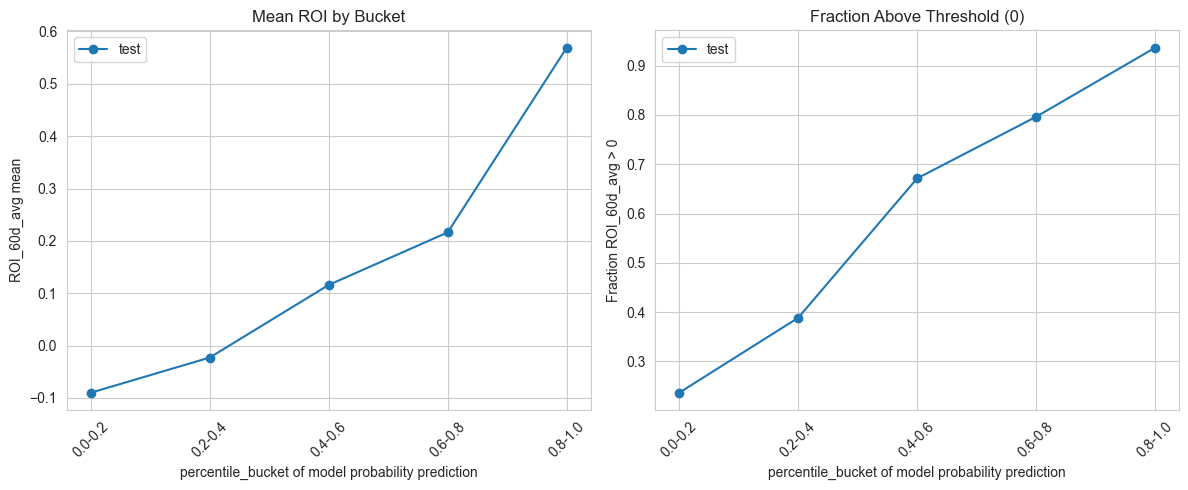

In [406]:
signal.plot_roi_summary_by_bucket(ROI_rank_RF,0)

### 2.4 LightGBM on target_up_60d

In [407]:
model_LGB = LGBMClassifier(random_state=42, objective = 'binary')
param_grid_LGB = {
    'max_depth': [5, 7],
    'n_estimators': [300, 500],
    'learning_rate': [0.01, 0.1],
    'colsample_bytree': [0.6, 0.8],
    'subsample': [0.6, 0.8],
    'reg_lambda': [1.5, 2],
    'reg_alpha': [0.1, 1],
}

grid_search_LGB = GridSearchCV(
    estimator=model_LGB,
    param_grid=param_grid_LGB,
    scoring='accuracy', # Choose an appropriate scoring metric
    cv=tscv,
    verbose=1,
    return_train_score=True,
    n_jobs=-1 # Use all available CPU cores
)

grid_search_LGB.fit(X_train.to_pandas(), y_train.to_pandas())

Fitting 5 folds for each of 128 candidates, totalling 640 fits
[LightGBM] [Info] Number of positive: 3121, number of negative: 1972
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9285
[LightGBM] [Info] Number of data points in the train set: 5093, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.612802 -> initscore=0.459105
[LightGBM] [Info] Start training from score 0.459105
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.6, 0.8], 'learning_rate': [0.01, 0.1], 'max_depth': [5, 7], 'n_estimators': [300, 500], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [408]:
print(grid_search_LGB.best_params_)
print(grid_search_LGB.best_score_)
model_LGB = grid_search_LGB.best_estimator_
# {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 1.5, 'subsample': 0.6}

{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'reg_alpha': 1, 'reg_lambda': 2, 'subsample': 0.6}
0.46155660377358493


In [409]:
accuracy_score(model_LGB.predict(X_test), y_test)

0.5547703180212014

SignificanceResult(statistic=np.float64(0.6189364718959758), pvalue=np.float64(1.2878615558214652e-48))


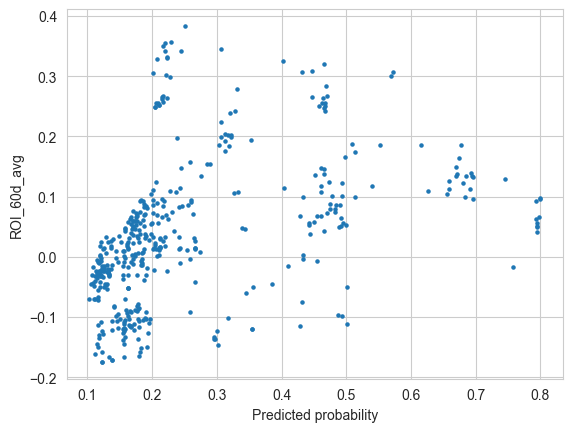

In [272]:
pred_prob_LGB = model_LGB.predict_proba(X_test)[60:,1]
plt.scatter(pred_prob_LGB, ROI_test[60:], s=5)
plt.ylabel('ROI_60d_avg')
plt.xlabel("Predicted probability")
print(spearmanr(pred_prob_LGB, ROI_test[60:], nan_policy='omit'))

In [410]:
rank_LGB = signal.get_rank(model_LGB, X, len(X_train), purge_len=60)
ROI_rank_LGB = signal.merge_ROI_rank(ROI, rank_LGB, purge_len=60)

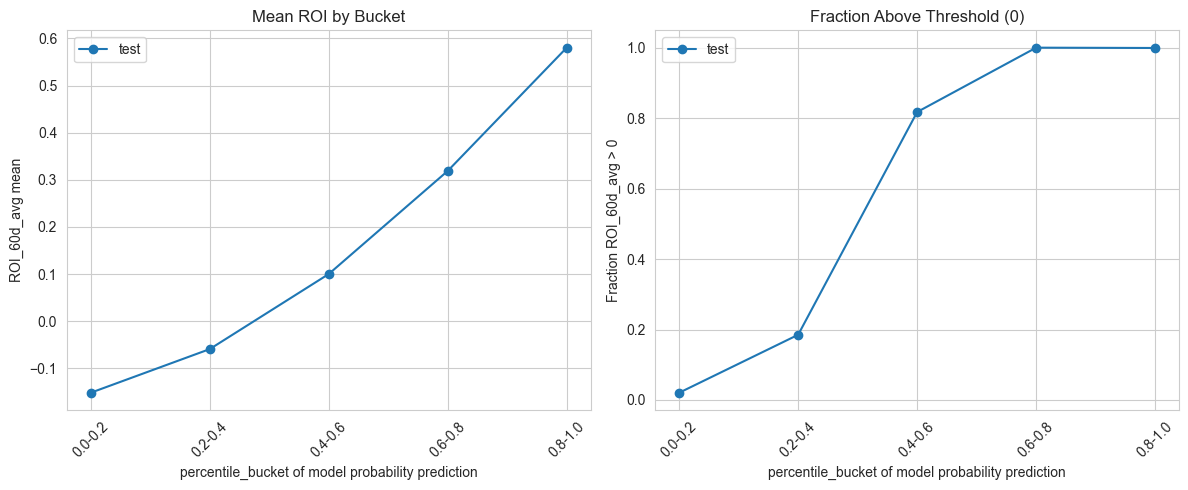

In [411]:
signal.plot_roi_summary_by_bucket(ROI_rank_LGB,0)

### 2.5. XGBoost on ROI_30d_top30

In [412]:
TARGET_COL = "target"
train, test, ROI_train, ROI_test = train_test_split(btc_df, btc_df[['ROI_30d']], test_size=0.2,
                                                                         random_state=42, shuffle=False)

In [413]:
q = train.select(pl.col("ROI_30d").quantile(0.7)).item()

train = train.with_columns(
    (pl.col("ROI_30d") >= q).cast(pl.Int8).alias("target")
)

test = test.with_columns(
    (pl.col("ROI_30d") >= q).cast(pl.Int8).alias("target")
)

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]
X_test = test[FEATURE_COLS]
y_test = test[TARGET_COL]

In [414]:
model_top30 = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42,
    colsample_bytree= 0.3, learning_rate= 0.01,
    max_depth= 5, n_estimators= 1000,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.3
)
model_top30.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.3
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [415]:
rank_top30 = signal.get_rank(model_top30, X_test, 0, 30)
ROI_rank_top30 = signal.merge_ROI_rank(ROI_test, rank_top30, 30)

SignificanceResult(statistic=np.float64(0.14624735150907536), pvalue=np.float64(1.5196467079416532e-06))


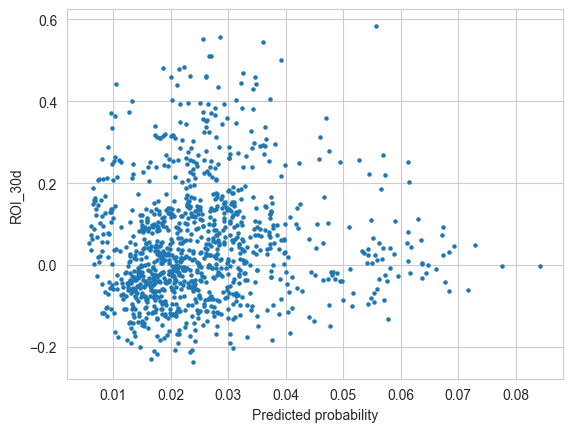

In [416]:
pred_prob_top30 = model_top30.predict_proba(X_test)[30:,1]
plt.scatter(pred_prob_top30, ROI_test[30:], s=5)
plt.ylabel('ROI_30d')
plt.xlabel("Predicted probability")
print(spearmanr(pred_prob_top30, ROI_test[30:], nan_policy='omit'))

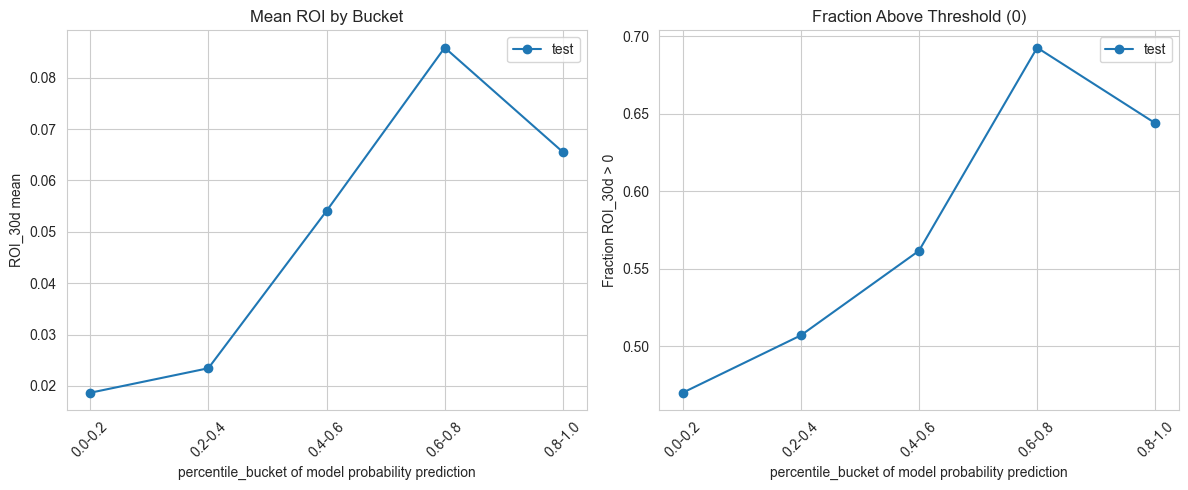

In [417]:
signal.plot_roi_summary_by_bucket(ROI_rank_top30,0)

percentile_bucket,test
str,f64
"""0.0-0.2""",0.470046
"""0.2-0.4""",0.507042
"""0.4-0.6""",0.561644
"""0.6-0.8""",0.692661
"""0.8-1.0""",0.643902


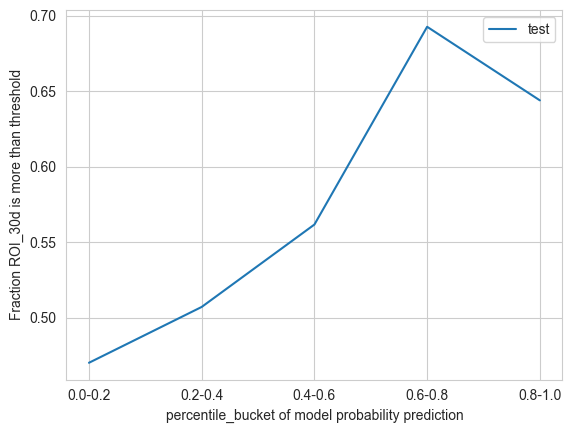

In [198]:
signal.plot_ROI_threshold(ROI_rank_top30)

### 2.6 XGBoost on Future_60d_min_rel

In [419]:
TARGET_COL = 'Future_60d_min_rel'
X = btc_df[FEATURE_COLS]
y = btc_df[TARGET_COL]
ROI = btc_df[['ROI_60d_avg']]
X_train, X_test, y_train, y_test, ROI_train, ROI_test = train_test_split(X, y, ROI, test_size=0.1,
                                                                         random_state=1, shuffle=False)

In [420]:
model_min = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    colsample_bytree= 0.3, learning_rate= 0.1,
    max_depth= 5, n_estimators= 1000,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.3
)
model_min.fit(X_train, y_train)
pred_min = model_min.predict(X_test)

SignificanceResult(statistic=np.float64(0.31413172966379693), pvalue=np.float64(4.73745465246335e-13))


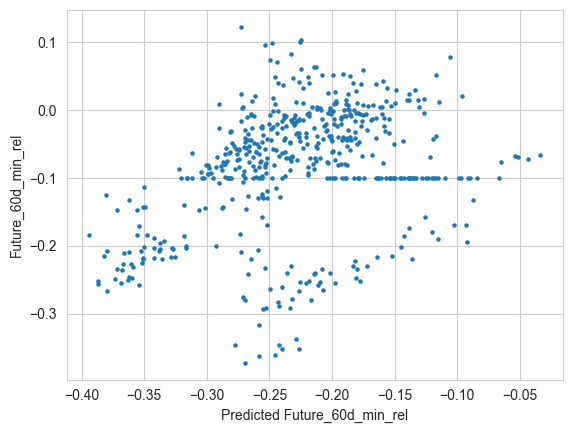

In [421]:
plt.scatter(pred_min[60:],y_test[60:],s = 5)
plt.ylabel('Future_60d_min_rel')
plt.xlabel("Predicted Future_60d_min_rel")
print(spearmanr(pred_min[60:], y_test[60:], nan_policy='omit'))

In [284]:
rank = pd.DataFrame(model_min.predict(X_test)).rank(pct=True)
rank = rank.rename(columns={0: 'percentile'})
rank['train_test'] = 'train'
# rank.iloc[len_train:(len_train+purge_len), rank.columns.get_loc('train_test')] = 'purge'
rank.iloc[60:, rank.columns.get_loc('train_test')] = 'test'

In [285]:
ROI_rank = pl.concat([pl.DataFrame(y_test[60:]), pl.from_pandas(rank)], how="horizontal")
p = pl.col('percentile')
ROI_rank = ROI_rank.with_columns(
    pl.when(p > 0.8).then(pl.lit('0.8-1.0'))
    .when(p > 0.6).then(pl.lit('0.6-0.8'))
    .when(p > 0.4).then(pl.lit('0.4-0.6'))
    .when(p > 0.2).then(pl.lit('0.2-0.4'))
    .when(p > 0).then(pl.lit('0.0-0.2'))
    .otherwise(pl.lit('unknown'))
    .alias('percentile_bucket')
)

percentile_bucket,test,train
str,f64,f64
"""0.0-0.2""",-0.101322,null
"""0.2-0.4""",-0.124739,null
"""0.4-0.6""",-0.112152,null
"""0.6-0.8""",-0.047627,-0.081353
"""0.8-1.0""",-0.029517,-0.01526


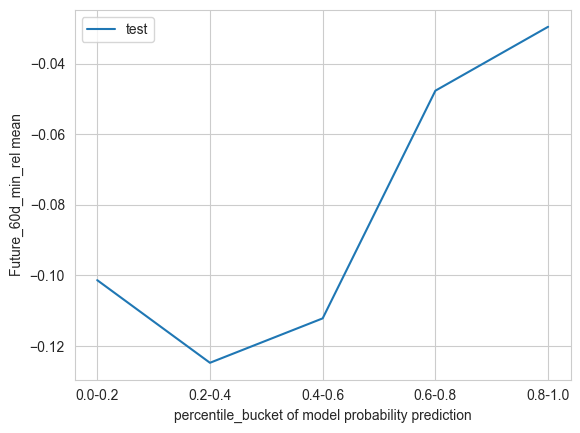

In [286]:
ROI_colname = 'Future_60d_min_rel'
grouped = (
    ROI_rank.filter(pl.col(ROI_colname).is_not_null())
    .group_by(['percentile_bucket', 'train_test'])
    .agg(pl.col(ROI_colname).mean())
    .sort('percentile_bucket')
).pivot("train_test", index="percentile_bucket", values=ROI_colname)
display(grouped)
# plt.plot(grouped['percentile_bucket'], grouped['train'])
plt.plot(grouped['percentile_bucket'], grouped['test'])
plt.legend(['test'])
plt.xlabel('percentile_bucket of model probability prediction')
plt.ylabel(f"{ROI_colname} mean")
plt.show()


## 3. Walk forward prediction

To generate the predictions for our backtesting window (2018-01-01 to 2025-12-31), the model is trained with walk-forward prediction. Each CYCLE_LEN-day period is predicted using all prior data up to PURGE_LEN days before the start of the current cycle. The PURGE_LEN data exclusion is intended to avoid forward data leakage from the target metric, e.g., target_up_60d will contain information up to the following 60 days profitability.

The walk-forward prediction for target_up_60d and Future_60d_min_rel exhibited poor correlation to target metrics (Figure 11, Figure 13), in contrast to the simple train-test split. The model performance significantly degrades during walk-forward validation. This indicates the signals identified during static validation do not generalize under realistic, sequential retraining situations.

On the other hand, training XGBoost on ROI_30d_top30 to produce prediction probability pred_top30 maintained its correlation to ROI_60d_avg although a lot of noise was also observed. Monotonous increase in ROI_60d_avg and fraction of ROI_60d_avg > 0 was also observed when data was broken down by quintile buckets (Figure 14), suggesting signal is consistent. One probable reason this target metric is more robust than target_up_60d is the larger separation from zero, which forced the model to learn only high confidence signals.


### 3.1 XGBoost on target_up_60d

In [296]:
COLS = btc_df.columns
COLS = btc_df.columns
EXCLUDE_COLS = ['time','future_30d_avg',
                'ROI_30d_avg',
                'target_up_30d',
                'target_up5_30d',
                'future_30d_vs_30d_SMA',
                'future_30d_min',
                'Price_per_30d_min',
                'target_rank_30d',
                'future_60d_avg',
                'ROI_60d_avg',
                'target_up_60d',
                'target_up5_60d',
                'future_60d_vs_30d_SMA',
                'future_60d_min',
                'Price_per_60d_min',
                'target_rank_60d',
                'ROI_30d',
                'ROI_30d_top30',
                'ROI_60d',
                'ROI_60d_top30','markPrice',
                'PriceUSD',
                'target_up_30d',
                'CapMrktCurUSD',
                'oc_MVRV_high',
                'future_30d_kmin_5',
                'future_60d_kmin_5',
                'Future_30d_min_rel',
                'Future_60d_min_rel',
                # 'smastd_200',
                # 'distance_sma_200'
                #'oc_CapMrktCurUSD_Z',
                ]
TARGET_COL = 'target_up_60d'
INDEX_COL = 'time_basis'

# FEATURE_COLS = 'oc_MVRVCur_Z'
FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL]
POLYMARKET_COL = [
    'poly_dtrade_count',
    'poly_dtrade_active_traders',
    'poly_dtrade_avg_trx',
    'poly_dtrade_trx',
    'poly_dtrade_trx_dir',
    'poly_dtrade_trx_std',
    'odds_markets',
    'odds_avg',
    'odds_dispersion',
    'odds_breadth',
    'odds_momentum',
    'odds_long_market',
    'odds_long_avg',
    'odds_short_market',
    'odds_short_avg',
    'odds_duration_divergence',
    'poly_dtrade_trx_zscore',
    'poly_dtrade_trx_dir_zscore',
    'odds_avg_zscore',
    'odds_long_zscore',
    'odds_short_zscore',
    'poly_dtrade_trx_dir_ratio',
]
NON_POLY_FEATURE_COLS = [col for col in COLS if col not in EXCLUDE_COLS and col not in TARGET_COL and col not in INDEX_COL and col not in POLYMARKET_COL]
POLYMARKET_START = pl.date(2025,4,7)

ONCHAIN_FEATURES = [
    'AdrActCnt',
    'AdrBalCnt',
    'BlkCnt',
    'CapMVRVCur',
    'FeeTotNtv',
    'HashRate',
    'TxCnt',
    'TxTfrCnt',
    'volume_reported_spot_usd_1d',
    'oc_MVRVCur_Z',
    'oc_MVRVCur_grad',
    'oc_MVRVCur_accel',
    'oc_CapMrktCurUSD_Z',
    'oc_Puell_proxy',
    'oc_miner_stress',
    'oc_flow_ratio',
    'oc_vol_30d_zscore',
    'oc_turnover',
]
TECHNICAL_FEATURES = [
    'smastd_200',
    'distance_sma_200',
    'emastd_200',
    'distance_ema_200',
    'drawdown',
]
MACRO_FEATURES = [
    'M2SL',
    'WALCL',
    'CPIAUCSL',
    'fed_balance_growth',
    'real_rate',
    'usd_strength',
    '10y_yield',
    'inflation_yoy'
]
BINANCE_FEATURES = [
    'bin_returns_1d',
    'bin_volatility_30d',
    'bin_volume_zscore',
    'funding_rate'
]

In [290]:
DATA_START = btc_df['time_basis'].min()
DATA_END = btc_df['time_basis'].max()
BACKTEST_START = date(2018, 1, 1)
CYCLE_LENGTH = 5
PURGE_LEN = 60

In [291]:
cycles = pl.date_range(
    start=BACKTEST_START,
    end=DATA_END,
    interval=str(CYCLE_LENGTH)+"d",
    eager=True
).alias("cycles")

In [292]:
model_cycle = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42,
    colsample_bytree= 0.3, learning_rate= 0.01,
    max_depth= 5, n_estimators= 500,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.3
)

In [297]:
ANNUAL_DECAY = [0.0]
STRAT_WEIGHTS = {'PRED_PROB_DECAY_'+str(key): np.array([]) for key in ANNUAL_DECAY}

for start_cycle in cycles:
    end_cycle = start_cycle + timedelta(days=CYCLE_LENGTH)
    train = btc_df.filter(pl.col('time_basis') < (start_cycle-timedelta(days=PURGE_LEN))) # ensure no leakage
    test = btc_df.filter((pl.col('time_basis') >= start_cycle)&(pl.col('time_basis') < end_cycle))
    X_train = train[FEATURE_COLS]
    X_test = test[FEATURE_COLS]
    y_train = train[TARGET_COL]
    y_test = test[TARGET_COL]
    X = pl.concat([X_train, X_test], how="vertical")

    for DECAY in ANNUAL_DECAY:
        KEY = 'PRED_PROB_DECAY_'+str(DECAY)
        multiplier = (1+DECAY)**(1/365)
        model_cycle.fit(X_train, y_train, sample_weight=multiplier**np.arange(len(y_train)))
        # rank = signal.get_rank(model_cycle, X, len(X_train), PURGE_LEN)
        # STRAT_WEIGHTS[KEY] = np.append(STRAT_WEIGHTS[KEY],(rank['percentile'][-len(test):]))

        rank = model_cycle.predict_proba(X_test)[:,1]
        STRAT_WEIGHTS[KEY] = np.append(STRAT_WEIGHTS[KEY],(rank[-len(test):]))


In [298]:
Price = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['PriceUSD']].to_pandas()
ROI_backtest = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['ROI_60d_avg']].to_pandas()
STRAT_WEIGHTS = pd.DataFrame(STRAT_WEIGHTS)

In [299]:
series = pl.from_pandas(STRAT_WEIGHTS['PRED_PROB_DECAY_0.0'])
window = 365
mean = series.rolling_mean(window_size=window, min_periods=window // 2)
std = series.rolling_std(window_size=window, min_periods=window // 2)
prob_target_up_60d_zscore = pl.DataFrame((series - mean) / std).rename(
    {'PRED_PROB_DECAY_0.0': 'prob_target_up_60d_zscore'})

Text(0, 0.5, 'ROI_60d_avg')

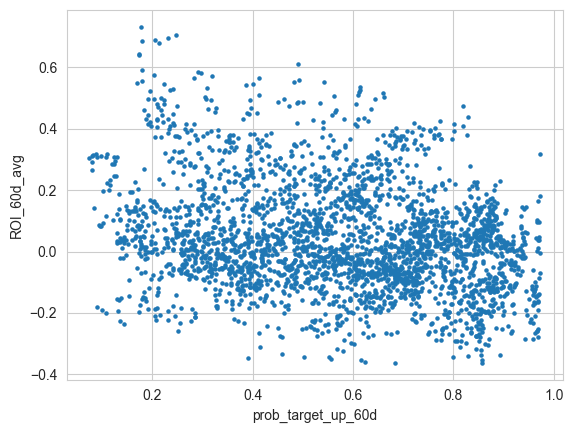

In [300]:
plt.scatter(STRAT_WEIGHTS['PRED_PROB_DECAY_0.0'], ROI_backtest, s=5)
plt.xlabel('prob_target_up_60d')
plt.ylabel('ROI_60d_avg')

Text(0, 0.5, 'ROI_60d_avg')

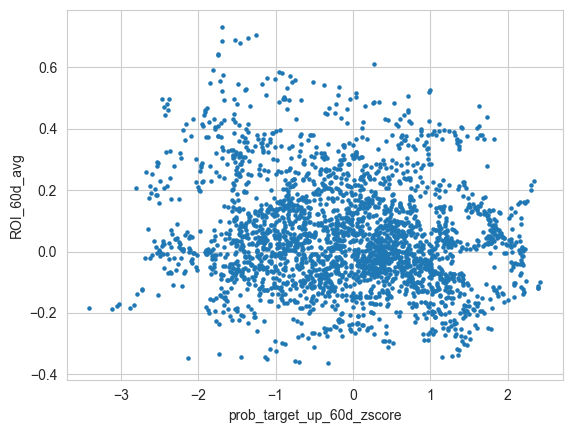

In [301]:
plt.scatter(prob_target_up_60d_zscore, ROI_backtest, s=5)
plt.xlabel('prob_target_up_60d_zscore')
plt.ylabel('ROI_60d_avg')

### 3.2 XGBoost on ROI_30d_top30

In [304]:
TARGET_COL = "target"
DATA_START = btc_df['time_basis'].min()
DATA_END = btc_df['time_basis'].max()
BACKTEST_START = date(2017, 1, 1)
CYCLE_LENGTH = 5
PURGE_LEN = 30
cycles = pl.date_range(
    start=BACKTEST_START,
    end=DATA_END,
    interval=str(CYCLE_LENGTH)+"d",
    eager=True
).alias("cycles")
model_cycle = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42,
    colsample_bytree= 0.3, learning_rate= 0.01,
    max_depth= 5, n_estimators= 1000,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.3
)
# Try a few values from 0.1 to 0.3
ANNUAL_DECAY = [0.0] #, 0.1, 0.2, 0.3

In [306]:
STRAT_WEIGHTS_Q = {'PRED_PROB_DECAY_'+str(key): np.array([]) for key in ANNUAL_DECAY}

for start_cycle in cycles:
    end_cycle = start_cycle + timedelta(days=CYCLE_LENGTH)
    train = btc_df.filter(pl.col('time_basis') < (start_cycle-timedelta(days=PURGE_LEN))) # ensure no leakage -timedelta(days=PURGE_LEN)
    test = btc_df.filter((pl.col('time_basis') >= start_cycle)&(pl.col('time_basis') < end_cycle))
    q = train.select(pl.col("ROI_30d").quantile(0.7)).item()

    train = train.with_columns(
        (pl.col("ROI_30d") >= q).cast(pl.Int8).alias("target")
    )

    test = test.with_columns(
        (pl.col("ROI_30d") >= q).cast(pl.Int8).alias("target")
    )

    X_train = train[FEATURE_COLS]
    X_test = test[FEATURE_COLS]
    y_train = train[TARGET_COL].fill_null(0)
    y_test = test[TARGET_COL].fill_null(0)
    X = pl.concat([X_train, X_test], how="vertical")

    for DECAY in ANNUAL_DECAY:
        KEY = 'PRED_PROB_DECAY_'+str(DECAY)
        multiplier = (1+DECAY)**(1/365)
        model_cycle.fit(X_train, y_train, sample_weight=multiplier**np.arange(len(y_train)))
        # rank = signal.get_rank(model_cycle, X, len(X_train), PURGE_LEN)
        # STRAT_WEIGHTS_Q[KEY] = np.append(STRAT_WEIGHTS_Q[KEY],(rank['percentile'][-len(test):]))

        rank = model_cycle.predict_proba(X_test)[:,1]
        STRAT_WEIGHTS_Q[KEY] = np.append(STRAT_WEIGHTS_Q[KEY],(rank[-len(test):]))
STRAT_WEIGHTS_Q = pd.DataFrame(STRAT_WEIGHTS_Q)


In [321]:
Price = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['PriceUSD']].to_pandas()
ROI_backtest = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['ROI_60d_avg']].to_pandas()

In [309]:
series=pl.from_pandas(STRAT_WEIGHTS_Q['PRED_PROB_DECAY_0.0'])
window = 365
mean = series.rolling_mean(window_size=window, min_periods=window // 2)
std = series.rolling_std(window_size=window, min_periods=window // 2)
prob_top30_z = pl.DataFrame((series - mean) / std).rename({'PRED_PROB_DECAY_0.0':'prob_top30_zscore'})

SignificanceResult(statistic=np.float64(0.13282179697683286), pvalue=np.float64(3.1154448835594665e-14))


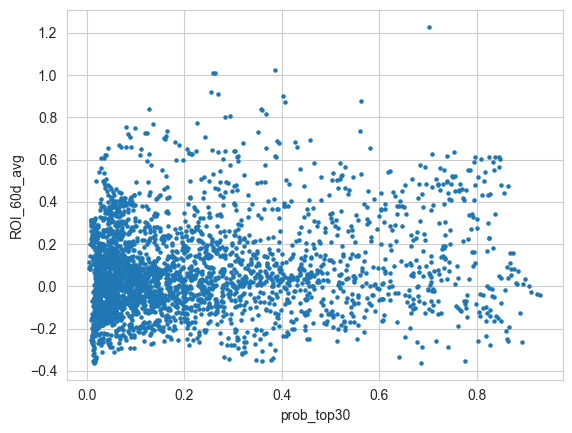

In [324]:
plt.scatter(series, ROI_backtest, s=5)
plt.xlabel('prob_top30')
plt.ylabel('ROI_60d_avg')
print(spearmanr(series, ROI_backtest, nan_policy='omit'))

SignificanceResult(statistic=np.float64(0.13282179697683286), pvalue=np.float64(3.1154448835594665e-14))


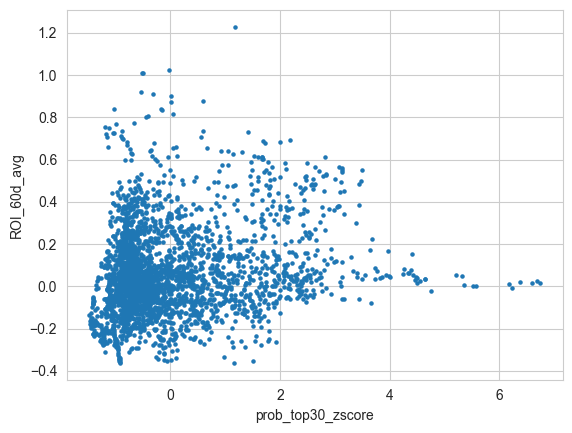

In [325]:
plt.scatter(prob_top30_z, ROI_backtest, s=5)
plt.xlabel('prob_top30_zscore')
plt.ylabel('ROI_60d_avg')
print(spearmanr(series, ROI_backtest, nan_policy='omit'))

Text(0.5, 0, 'prob_top30_zscore')

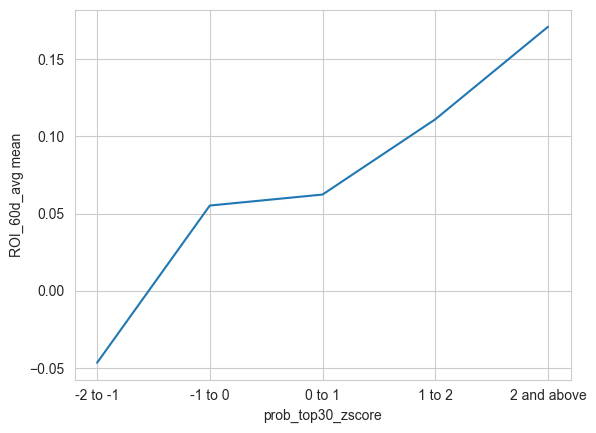

In [338]:
ROI_rank = pl.concat([pl.from_pandas(ROI_backtest), prob_top30_z], how="horizontal")
p = pl.col('prob_top30_zscore')
g = (ROI_rank.with_columns(
    pl.when(p > 2).then(pl.lit('2 and above'))
    .when(p > 1).then(pl.lit('1 to 2'))
    .when(p > 0).then(pl.lit('0 to 1'))
    .when(p > -1).then(pl.lit('-1 to 0'))
    .when(p > -2).then(pl.lit('-2 to -1'))
    .otherwise(pl.lit('unknown'))
    .alias('z_bucket')
).filter(p.is_not_null())
             .group_by(['z_bucket'])
             .agg(pl.col("ROI_60d_avg").mean())).sort("ROI_60d_avg")
plt.plot(g['z_bucket'], g['ROI_60d_avg'])
plt.ylabel('ROI_60d_avg mean')
plt.xlabel('prob_top30_zscore')

Text(0.5, 0, 'prob_top30_zscore')

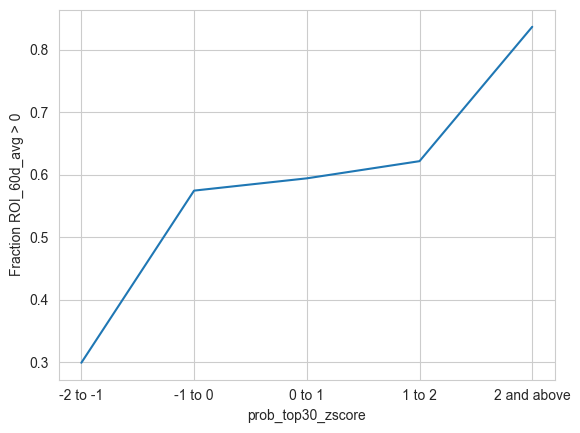

In [343]:
g_med = (ROI_rank.with_columns(
    pl.when(p > 2).then(pl.lit('2 and above'))
    .when(p > 1).then(pl.lit('1 to 2'))
    .when(p > 0).then(pl.lit('0 to 1'))
    .when(p > -1).then(pl.lit('-1 to 0'))
    .when(p > -2).then(pl.lit('-2 to -1'))
    .otherwise(pl.lit('unknown'))
    .alias('z_bucket')
).filter(p.is_not_null())
             .group_by(['z_bucket'])
             .agg((pl.col("ROI_60d_avg")>0).mean())).sort("ROI_60d_avg")
plt.plot(g_med['z_bucket'], g_med['ROI_60d_avg'])
plt.ylabel('Fraction ROI_60d_avg > 0')
plt.xlabel('prob_top30_zscore')

In [353]:
prob_top30 = STRAT_WEIGHTS_Q.rename(columns={'PRED_PROB_DECAY_0.0':'prob_top30'})
prob_top30 = pd.concat([prob_top30, prob_top30_z.to_pandas()], axis=1)
prob_top30.set_index(btc_df.filter(pl.col('time_basis') >= BACKTEST_START)['time_basis'].to_pandas(), inplace=True)
prob_top30.index.name = 'time'

In [1362]:
# prob_top30.to_parquet('prob_top30.parquet')

### 3.3 XGBoost on Future_60d_min_rel

In [341]:
TARGET_COL = 'Future_60d_min_rel'

DATA_START = btc_df['time_basis'].min()
DATA_END = btc_df['time_basis'].max()
BACKTEST_START = date(2017, 1, 1)
CYCLE_LENGTH = 90
PURGE_LEN = 60
cycles = pl.date_range(
    start=BACKTEST_START,
    end=DATA_END,
    interval=str(CYCLE_LENGTH)+"d",
    eager=True
).alias("cycles")
model_cycle = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    colsample_bytree= 0.3, learning_rate= 0.1,
    max_depth= 5, n_estimators= 1000,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.3
)
# Try a few values from 0.1 to 0.3
ANNUAL_DECAY = [0.0] #, 0.1, 0.2, 0.3

In [342]:
STRAT_WEIGHTS = {'TARGET_DECAY_'+str(key): np.array([]) for key in ANNUAL_DECAY}

for start_cycle in cycles:
    end_cycle = start_cycle + timedelta(days=CYCLE_LENGTH)
    train = btc_df.filter(pl.col('time_basis') < (start_cycle-timedelta(days=PURGE_LEN))) # ensure no leakage -timedelta(days=PURGE_LEN)
    test = btc_df.filter((pl.col('time_basis') >= start_cycle)&(pl.col('time_basis') < end_cycle))
    X_train = train[FEATURE_COLS]
    X_test = test[FEATURE_COLS]
    y_train = train[TARGET_COL].fill_null(0)
    y_test = test[TARGET_COL].fill_null(0)
    X = pl.concat([X_train, X_test], how="vertical")

    for DECAY in ANNUAL_DECAY:
        KEY = 'TARGET_DECAY_'+str(DECAY)
        multiplier = (1+DECAY)**(1/365)
        model_cycle.fit(X_train, y_train, sample_weight=multiplier**np.arange(len(y_train)))
        # rank = signal.get_rank(model_cycle, X, len(X_train), PURGE_LEN)
        # STRAT_WEIGHTS[KEY] = np.append(STRAT_WEIGHTS[KEY],(rank['percentile'][-len(test):]))

        rank = model_cycle.predict(X_test)
        STRAT_WEIGHTS[KEY] = np.append(STRAT_WEIGHTS[KEY],(rank[-len(test):]))
STRAT_WEIGHTS = pd.DataFrame(STRAT_WEIGHTS)


In [344]:
Price = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['PriceUSD']].to_pandas()
ROI_backtest = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[['ROI_30d_avg']].to_pandas()
y_test = btc_df.filter(pl.col('time_basis') >= BACKTEST_START)[TARGET_COL].fill_null(0.8)

In [346]:
min_ratio_log_pred = STRAT_WEIGHTS[['TARGET_DECAY_0.0']].rename(columns={'TARGET_DECAY_0.0':'min_ratio_log_pred'})
series = pl.from_pandas(min_ratio_log_pred['min_ratio_log_pred'])
window = 365
mean = series.rolling_mean(window_size=window, min_periods=window // 2)
std = series.rolling_std(window_size=window, min_periods=window // 2)
min_ratio_log_pred_zscore = pd.DataFrame((series - mean) / std).rename(columns={0:'min_ratio_log_pred_zscore'})

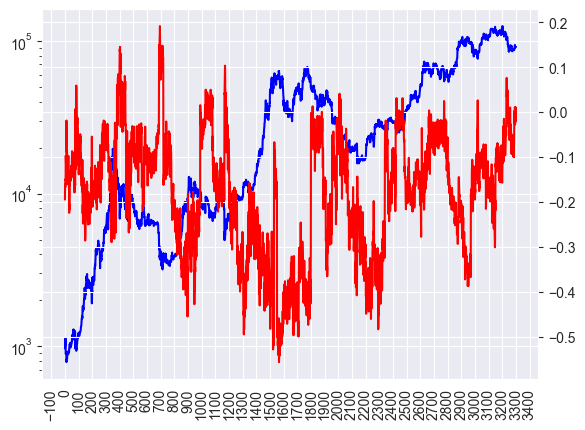

In [1571]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

fig, ax1 = plt.subplots()

# First plot (Left Y-axis)
ax1.semilogy(Price, color='blue')

# Create secondary Y-axis (Right Y-axis)
ax2 = ax1.twinx()
ax2.plot(STRAT_WEIGHTS['TARGET_DECAY_0.0'], color='red')

ax1.xaxis.set_major_locator(MultipleLocator(100))
plt.grid(True)
ax1.tick_params(axis='x', labelrotation=90)

SignificanceResult(statistic=np.float64(-0.021209837605311255), pvalue=np.float64(0.22319060152185516))


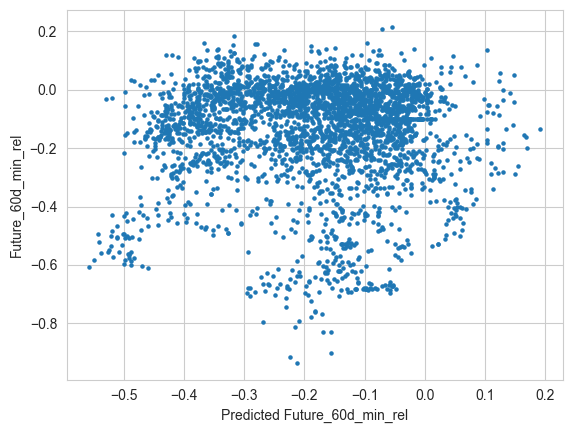

In [355]:
plt.scatter(series,y_test, s=5)
plt.xlabel('Predicted Future_60d_min_rel')
plt.ylabel('Future_60d_min_rel')
print(spearmanr(series, y_test, nan_policy='omit'))

SignificanceResult(statistic=np.float64(-0.10315725298866225), pvalue=np.float64(7.730686437765779e-09))


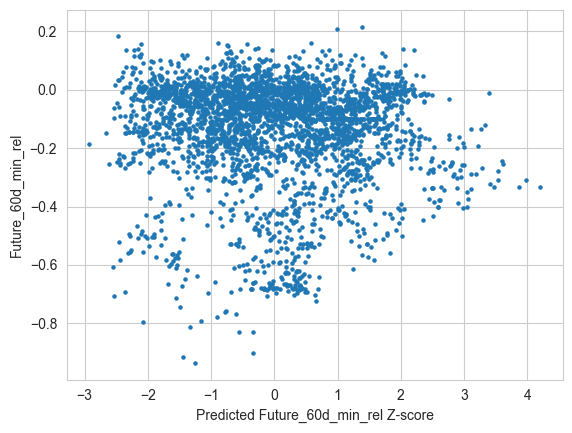

In [356]:
plt.scatter(min_ratio_log_pred_zscore,y_test, s=5)
plt.xlabel('Predicted Future_60d_min_rel Z-score')
plt.ylabel('Future_60d_min_rel')
print(spearmanr(min_ratio_log_pred_zscore, y_test, nan_policy='omit'))

In [1590]:
# min_ratio_log_pred.set_index(btc_df.filter(pl.col('time_basis') >= BACKTEST_START)['time_basis'].to_pandas(), inplace=True)
# min_ratio_log_pred.index.name = 'time'
# min_ratio_log_pred.to_parquet('min_gap.parquet')

## 4. Feature Contribution Using SHAP

The SHAP (SHapley Additive exPlanations) values uses a game-theoretic approach to quantify the contribution of each feature to the predicted output of machine learning models. The SHAP values from ROI_30d_top30 are reviewed here as this model showed the strongest signal.

In [360]:
TARGET_COL = "target"
train = btc_df.filter(pl.col('ROI_30d').is_not_null())
ROI_train = btc_df[['ROI_30d']]

q = train.select(pl.col("ROI_30d").quantile(0.7)).item()

train = train.with_columns(
    (pl.col("ROI_30d") >= q).cast(pl.Int8).alias("target")
)

X = train[FEATURE_COLS]
y = train[TARGET_COL]

model_top30 = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42,
    colsample_bytree= 0.3, learning_rate= 0.01,
    max_depth= 5, n_estimators= 1000,
    reg_alpha= 0.1, reg_lambda= 2, subsample= 0.3
)

model_top30.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.3
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [361]:
background = X.to_pandas().sample(min(200, len(X)), random_state=42)
background.columns = [str(c) for c in background.columns]

X_shap = X.to_pandas()
X_shap.columns = [str(c) for c in X_shap.columns]

explainer = shap.TreeExplainer(
    model,
    data=background,
    feature_perturbation="interventional",
    model_output="probability"
)

shap_values = explainer(X_shap)


100%|===================| 5627/5629 [00:58<00:00]        

The top 10 features and the directional impact of each feature are shown in Figure 15. Each instance is placed on individual feature row, and the x-axis represents the impact to model output. For example, low (blue points) from “distance_sma_200” feature have positive model output impact. The model probability changes with each instance (time) and with varying feature contributions as seen in the heatmap

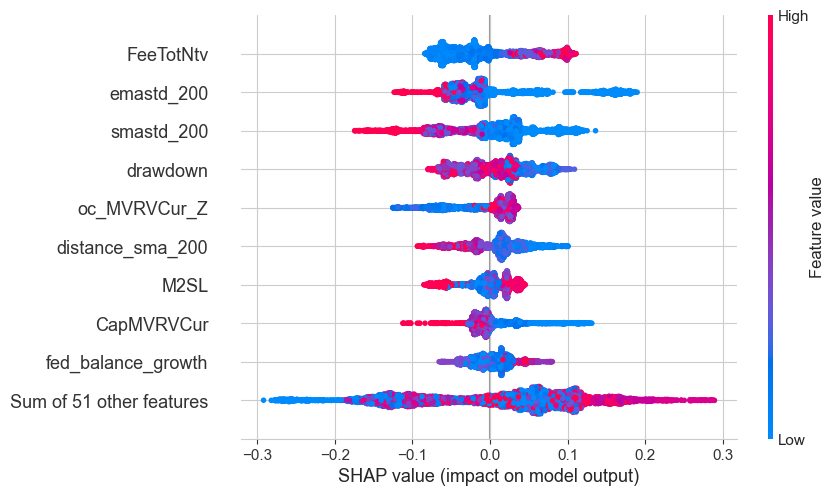

In [363]:
shap.plots.beeswarm(shap_values, max_display=10)

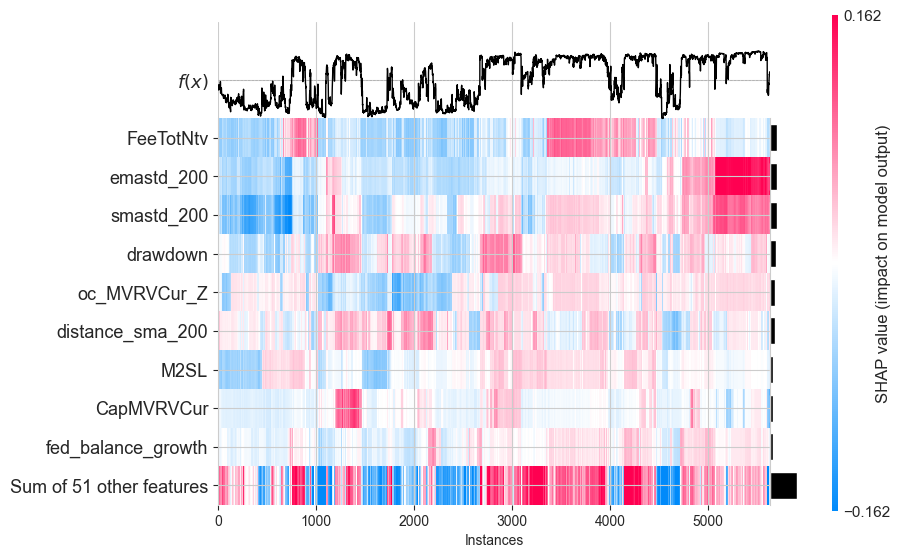

<Axes: xlabel='Instances'>

In [373]:
shap.plots.heatmap(shap_values, max_display=10)

Table lists directional impact of the top features and the possible explanations why these relationships are observed. The relationships are intuitive except for oc_MVRVCur_Z (MVRV Z-score) which suggests higher returns are more likely when the Z-score is high. This means the model captured the upwards momentum when Bitcoin prices are increasing relative to the Z-score rolling window, which is 365 days for this metric.

| Feature name   | Model favors feature value which is | Possible explanation                                  |
|----------------|-------------------------------------|-------------------------------------------------------|
| FeeTotNtv      | high                                | high network usage                                    |
| emastd_200     | low                                 | low volatility is less risky for accumulation         |
| smastd_200     | low                                 | low volatility is less risky for accumulation         |
| drawdown       | low                                 | buy when cheaper                                      |
| oc_MVRVCur_Z   | high                                | probably captures momentum instead of value signal    |
| distance_sma_200 | low                                 | buy when cheaper                                      |
| CapMVRVCur     | low                                 | value signal to buy when low                          |
| fed_balance_growth | high | indicates quantitative easing and more cash injection |

Figure shows the impact of the top features which exhibit distributed contribution instead of a small number of dominant features.

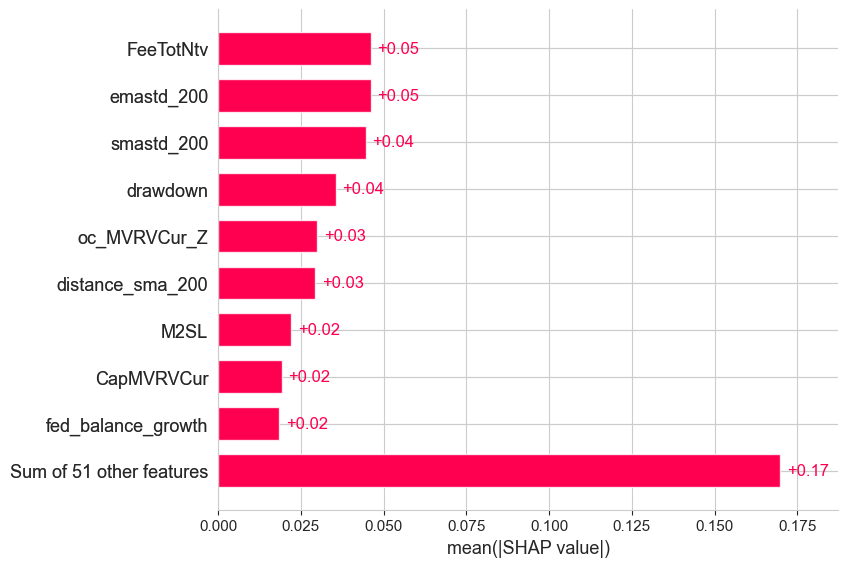

In [368]:
shap.plots.bar(shap_values, max_display=10)

Figure categorizes each feature and shows that Technical, On-Chain, and Macro features dominated while Polymarket and Binance features had limited contribution. Hence, despite extensive work on Polymarket features, the model was unable to utilize it. One explanation is the complete Polymarket data is only available since April 2025, which limits its testing to very recent time periods. With more data availability in the feature, Polymarket data may prove to be useful for Bitcoin accumulation signal.

Text(0, 0.5, 'Percent contribution')

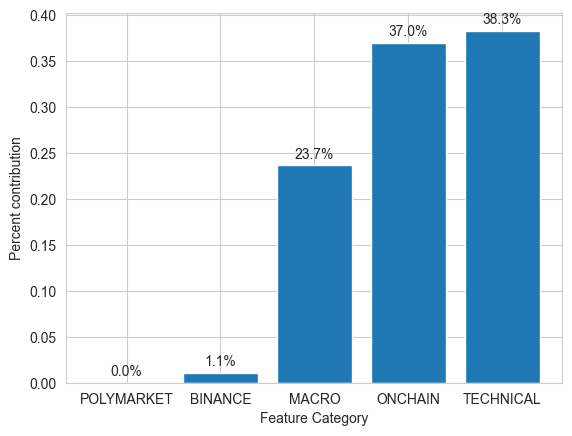

In [383]:
shap_col = pl.DataFrame({'colname':X.columns, 'shap':np.abs(shap_values.values).mean(axis=0)})
shap_agg = shap_col.with_columns(
    pl.when(pl.col('colname').is_in(POLYMARKET_COL)).then(pl.lit('POLYMARKET'))
    .when(pl.col('colname').is_in(ONCHAIN_FEATURES)).then(pl.lit('ONCHAIN'))
    .when(pl.col('colname').is_in(BINANCE_FEATURES)).then(pl.lit('BINANCE'))
    .when(pl.col('colname').is_in(TECHNICAL_FEATURES)).then(pl.lit('TECHNICAL'))
    .when(pl.col('colname').is_in(MACRO_FEATURES)).then(pl.lit('MACRO'))
    .alias('COL_CATEGORY')
).group_by(pl.col('COL_CATEGORY')).agg(pl.col('shap').sum()/shap_col['shap'].sum()).sort(pl.col('shap'))
bars = plt.bar(shap_agg['COL_CATEGORY'], shap_agg['shap'])
pct_labels = [f'{v*100:.1f}%' for v in shap_agg['shap']]
plt.bar_label(bars, labels=pct_labels, padding=3)
plt.xlabel('Feature Category')
plt.ylabel('Percent contribution')